# 20 — Phonons at $\Gamma$: differentiating the force

Notebook 09 computed the **force** as `jax.grad` of the total energy at frozen
wavefunctions. This one differentiates that gradient once more and gets the **force
constants** — and with them the frequencies at which silicon's atoms vibrate.

The whole of it is that one extra derivative. Write the energy as a function
$L(u, \psi)$ of where the atoms are and what the states are, carrying the orthonormality
constraint with its multipliers so that $L$ is *stationary* in $\psi$ at the solution —
which is exactly what made the force a partial derivative in the first place. Then

$$ \frac{\partial E}{\partial u_j} = \partial_j L, \qquad
   \frac{\partial^2 E}{\partial u_i\,\partial u_j}
   = \underbrace{\partial_i \partial_j L}_{\text{atoms move}}
   + \underbrace{(\partial_\psi \partial_j L)\cdot \frac{d\psi}{du_i}}_{\text{electrons follow}} $$

with no second-order wavefunction and no factor to get right. The two terms are components
of **one** tangent vector, so a single `jvp` of `jax.grad(L)` per mode returns a whole
column of the matrix.

| | what `ph.x` does | what happens here |
|---|---|---|
| $\partial_i\partial_j L$, the frozen second derivative | `dynmat0.f90`, `d2ionq.f90`, `dynmatcc.f90` | the $u$ half of one `jvp` |
| $(\partial_\psi \partial_j L)\cdot d\psi$, the response | `drhodv.f90` | the $\psi$ half of the *same* `jvp` |
| $dV_{\rm bare}/du\,|\psi\rangle$ | `dvqpsi_us.f90`, term by term | one `jvp` through `at_positions` |
| $dV_{\rm scf}/d\rho$, the screening | `dv_of_drho.f90` + a tabulated $f_{\rm xc}$ | one `jvp` of `v_of_rho` |
| the linear solve, `symdvscf`, `symdynph_gq`, `dyndia` | — | transcribed |

On the silicon of QE's `test-suite/ph_base`, against the `ph.x` that is vendored here:

| | pypresso | `ph.x` |
|---|---|---|
| optical mode ($\Gamma_{25'}$, triply degenerate) | **510.102** cm⁻¹ | 510.152 |
| acoustic modes (zero by translation invariance) | 4.09 | 2.05 |

The optical mode agrees to $9.7\times10^{-5}$ relative — the same floor as the dielectric
constant of notebook 19, and the same cause. The acoustic residue is *not* a target: see §4.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.response import dynamical_matrix
from pypresso.scf import Calculation, run_scf
from pypresso.system import build_system

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")

system = build_system(read_pw_input(CASES / "si-epsilon.in"))
pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
calculation = Calculation(system, pseudos)
scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-12)

print(f"total energy   {scf.total_energy:.9f} Ry")
print(f"pw.x           -15.84452726 Ry")

total energy   -15.844527263 Ry
pw.x           -15.84452726 Ry


## 1. The dynamical matrix

One call. Inside it: a bare perturbation per mode (six here), a self-consistent loop over
all of them together, and then six `jvp`s of the force's own gradient.

In [2]:
phonons = dynamical_matrix(
    calculation, scf.wavefunctions, scf.eigenvalues, scf.density, scf.becsum,
)

print(f"converged in {len(phonons.history)} iterations, "
      f"{phonons.average_iterations:.0f} CG steps per band per solve")
print()
for n, f in enumerate(phonons.frequencies):
    print(f"  freq ({n + 1}) = {f:12.6f} cm-1")
print()
print("  ph.x:      2.045258 x3,   510.151844 x3")

converged in 17 iterations, 28 CG steps per band per solve

  freq (1) =     4.087868 cm-1
  freq (2) =     4.087868 cm-1
  freq (3) =     4.087868 cm-1
  freq (4) =   510.102374 cm-1
  freq (5) =   510.102374 cm-1
  freq (6) =   510.102374 cm-1

  ph.x:      2.045258 x3,   510.151844 x3


The force constants themselves, in Ry/bohr². Two atoms, so a $6\times6$ matrix — and
because the two silicons are related by symmetry there are only two independent numbers in
it:

In [3]:
on_site = phonons.matrix[0, :, 0, :]
between = phonons.matrix[0, :, 1, :]
print("D[Si_1, Si_1] =\n", np.round(on_site, 9))
print("D[Si_1, Si_2] =\n", np.round(between, 9))
print()
print(f"isotropic on-site block to      {np.abs(on_site - np.eye(3) * on_site[0, 0]).max():.1e}")
print(f"asymmetry max|D - D^T|          {phonons.asymmetry:.1e}")
print(f"acoustic sum rule D_00 + D_01   {on_site[0, 0] + between[0, 0]:.3e}")

D[Si_1, Si_1] =
 [[ 0.276582  0.       -0.      ]
 [ 0.        0.276582 -0.      ]
 [-0.       -0.        0.276582]]
D[Si_1, Si_2] =
 [[-0.27654648  0.          0.        ]
 [ 0.         -0.27654648 -0.        ]
 [-0.         -0.         -0.27654648]]

isotropic on-site block to      4.2e-17
asymmetry max|D - D^T|          2.2e-16
acoustic sum rule D_00 + D_01   3.552e-05


## 2. What a phonon actually is

The optical mode is the two sublattices moving against each other, and what makes it cost
energy is the charge that has to rearrange when they do. `Phonons.induced_density` is that
charge: $d\rho/du$ for each atom and direction, on the dense grid.

**Left**, the charge induced by displacing one silicon along $x$, summed down one crystal
axis so that the whole cell is in view. It is antisymmetric about the displacement, as it
has to be — charge leaves one side of an atom and arrives on the other — and the second
sublattice, which has not moved, responds too. That rearrangement is the screening, and
paying for it is most of what makes the optical mode cost 510 cm⁻¹ rather than nothing.

**Right**, the check that costs nothing and tests everything. Displace *every* atom by the
same vector and the crystal has merely been translated, so the response must be the
ground-state density's own gradient, $\sum_a d\rho_{a,x} = -\partial\rho/\partial x$. The
right-hand side comes from differentiating $\rho$ in $G$-space and shares no machinery with
the left. They agree to $6.5\times10^{-5}$ — but only because the response is *screened*:
with the bare perturbation alone the two curves differ by 52%.

max relative difference over the whole grid: 6.5e-05


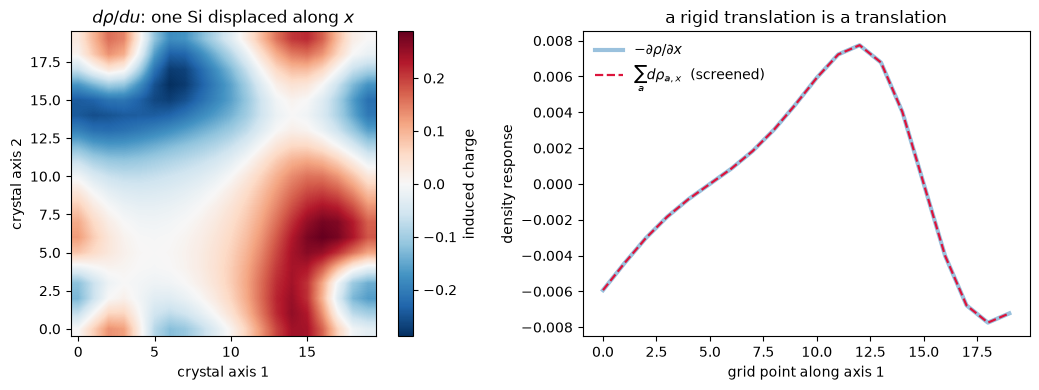

In [4]:
from pypresso.basis.fft import g_to_r, r_to_g

gvectors = calculation.basis.dense
rho_g = r_to_g(np.asarray(scf.density)[0], gvectors.fft_index)
cartesian = gvectors.cartesian(calculation.system.cell)
exact = -np.real(g_to_r(1j * cartesian[:, 0] * rho_g, gvectors.fft_index, gvectors.grid))
translated = phonons.induced_density[:, 0, 0].sum(axis=0)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.0))

one_atom = phonons.induced_density[0, 0, 0].sum(axis=2)
limit = np.abs(one_atom).max()
image = left.imshow(one_atom.T, origin="lower", cmap="RdBu_r",
                    vmin=-limit, vmax=limit, interpolation="bilinear")
left.set(title=r"$d\rho/du$: one Si displaced along $x$",
         xlabel="crystal axis 1", ylabel="crystal axis 2")
fig.colorbar(image, ax=left, label="induced charge")

line = np.s_[:, 5, 5]
grid = np.arange(exact.shape[0])
right.plot(grid, exact[line], lw=3, alpha=0.45, label=r"$-\partial\rho/\partial x$")
right.plot(grid, translated[line], "--", lw=1.6, color="crimson",
           label=r"$\sum_a d\rho_{a,x}$  (screened)")
right.set(title="a rigid translation is a translation", xlabel="grid point along axis 1",
          ylabel="density response")
right.legend(frameon=False)
fig.tight_layout()

error = np.abs(translated - exact).max() / np.abs(exact).max()
print(f"max relative difference over the whole grid: {error:.1e}")

## 3. How it is checked

`ph.x` is one of four references, and the other three exist because the assembly is a
derivative rather than a transcription — there is no Fortran expression here to compare
line by line, so every check has to come from outside.

| check | what it reaches | result |
|---|---|---|
| a rigid translation reproduces $-\partial\rho/\partial x$ | the solve, the kernel, the symmetrisation | 6.5e-5 relative |
| finite-differenced forces (displace, re-converge, difference) | the **response** half of the derivative | 2.1e-5 Ry/bohr² of 0.2865 |
| the wedge against the whole closed grid | the two symmetrisations | 2.7e-14 |
| `ph.x` frequencies | all of it | 0.05 cm⁻¹ |

The second is the one that matters most, and it is worth saying why: differentiating the
force with respect to the positions alone would give back the frozen Hessian and check
nothing. Only a *re-converged* SCF has let the wavefunctions relax, so only a finite
difference of converged forces sees the term the Sternheimer solve supplies. It is quoted
here rather than run — two extra SCF runs per column, on the unshifted grid that is closed
under the point group (`tests/regression/test_phonons.py`).

## 4. The acoustic modes, which are a diagnostic and not an answer

Translating a crystal costs no energy, so three frequencies are zero *exactly*. What comes
out instead — 4.09 cm⁻¹ here, 2.05 from `ph.x` — is the plane-wave basis's own error: the
basis does not follow the atoms, so the energy depends slightly on where they sit relative
to it. Both numbers are $10^{-4}$ of the force constants, and neither is physics.

`ph.x` does not impose the sum rule, so neither does this by default: the residue is the
cheapest diagnostic there is, and hiding it would hide a real error just as effectively.
`acoustic_sum_rule=True` imposes it when a spectrum is what is wanted.

In [5]:
imposed = dynamical_matrix(
    calculation, scf.wavefunctions, scf.eigenvalues, scf.density, scf.becsum,
    acoustic_sum_rule=True,
)
print("without the sum rule:", np.array2string(phonons.frequencies, precision=3))
print("with it            :", np.array2string(imposed.frequencies, precision=3))

without the sum rule: [  4.088   4.088   4.088 510.102 510.102 510.102]
with it            : [-3.053e-06  2.921e-06  6.547e-06  5.101e+02  5.101e+02  5.101e+02]


## 5. The trap, which cost the entire answer

`frozen_energy` — the functional notebook 09 differentiates for the force — builds its
density with the SCF's own **scalar** symmetrisation. That is right for a ground state: it
is how a sum over the irreducible wedge is completed to the whole Brillouin zone, and the
functional has to be the one the SCF minimised.

It is wrong for a *response*. Displacing one atom breaks the crystal's symmetry, and
averaging the result over the full group of the **undisplaced** crystal projects most of
the perturbation away. A second derivative differentiates that functional with respect to
the states, so left alone the chain rule pushes the state tangent straight through the
average. What that gave was not an obviously broken number:

| | chain rule through the scalar average | correct |
|---|---|---|
| optical mode | 667.0 cm⁻¹ | 510.1 |
| acoustic sum rule $D_{00} + D_{01}$ | −0.716 Ry/bohr² | 3.6e-5 |
| cubic, symmetric, converged | ✓ | ✓ |

The fix is that the density becomes an *independent argument* of the functional, so the
caller supplies its tangent too — the response density, averaged the way `symdvscf`
averages one, with the atom permutation beside the rotation. It is the rule the Sternheimer
solver's `density_at` already carried ("without the symmetrisation, because the caller
symmetrises it as a vector"), met for the first time in a **second** derivative.

The control that located it was free: the `nosym` run, which symmetrises nothing at all,
satisfied the sum rule to 4e-5 the whole time.

## 6. What is refused

Ultrasoft and PAW, and not because a routine is missing. The identity in the header holds
because $L$ is stationary in $\psi$ at *fixed* multipliers, and those multipliers sit on the
constraint $\langle\psi|S(u)|\psi\rangle = 1$. Differentiating twice leaves a term in
$d\varepsilon/du$ that vanishes identically when $S$ does not move with the atoms — a
norm-conserving dataset — and does not otherwise. The augmentation charge moves at frozen
`becsum` besides.

With the guard lifted, ultrasoft silicon's optical mode comes out at **−504.3 cm⁻¹**
against `ph.x`'s **+513.3**: imaginary where the crystal is stable, from a run that
converges cleanly and gives a matrix that is cubic and symmetric to $10^{-16}$. That is
what a refusal is for.

In [6]:
us = build_system(read_pw_input(CASES / "si-epsilon-us.in"))
us_pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in us.structure.species)
try:
    dynamical_matrix(Calculation(us, us_pseudos), None, np.zeros((1, 1, 1)), None)
except NotImplementedError as refusal:
    print(refusal)

the dynamical matrix with an ultrasoft or PAW pseudopotential is not implemented: the overlap operator moves with the atoms, so the orthonormality multipliers contribute a term of their own to the second derivative, and the augmentation charge Q_ij(r - tau) moves at frozen becsum (addusdynmat, drhodvus). Without them the norm-conserving expression gives ultrasoft silicon -504.3 cm^-1 against ph.x's +513.3 -- imaginary where the crystal is stable -- while converging cleanly and coming out cubic. The dielectric constant from the same solver is unaffected and is right for these datasets


---

**Where the detail lives.** `PLAN.md` §3, phase P25 — the derivation, the two
symmetrisations, the traps and every refusal with the number behind it. The tests are
`tests/regression/test_phonons.py`; the code is `pypresso/response/phonon.py`.

**What is left.** This is $\Gamma$ only. A phonon at $q \neq 0$ needs the perturbed states
at $k + q$ as well as at $k$ — two plane-wave spheres per k-point, which is machinery the
spin spirals (notebook 12) already built and which nothing here reuses yet. With that, and
`q2r`/`matdyn`'s Fourier interpolation, there is a dispersion; without it there is one point
of one.